# Clustering Reproducibility Analysis

UMAP and Leiden clustering involve stochastic elements. This notebook demonstrates that
the saved clustering result used in the paper is representative by comparing it against
freshly generated clustering runs with different random seeds.

In [3]:
import anndata as ad
import os
import numpy as np
import scanpy as sc
import harmonypy as hm
import umap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

## 1. Load the matrix with clustering shown in Fig. 5

In [5]:
adata_saved_1st = ad.read_h5ad('input/harmony_27_clusters_1st_brain.h5ad')
print("\nSaved (1st brain):")
print(adata_saved_1st)
print(f"Leiden clusters: {adata_saved_1st.obs['leiden'].nunique()}")
print(f"Cells: {adata_saved_1st.n_obs}")


Saved (1st brain):
AnnData object with n_obs × n_vars = 194824 × 15
    obs: 'cluster', 'leiden', 'batch', 'z_layer', 'dataset'
    uns: 'dataset_colors', 'leiden', 'leiden_colors', 'neighbors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'spatial', 'spatial3d'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
Leiden clusters: 27
Cells: 194824


## 3. Load Harmony

In [7]:
adata_both = ad.read_h5ad('input/adata_plot_harmony_ave_int_2_brains.h5ad')

C:\Users\liany\AppData\Local\anaconda3\Lib\site-packages\anndata\_core\anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


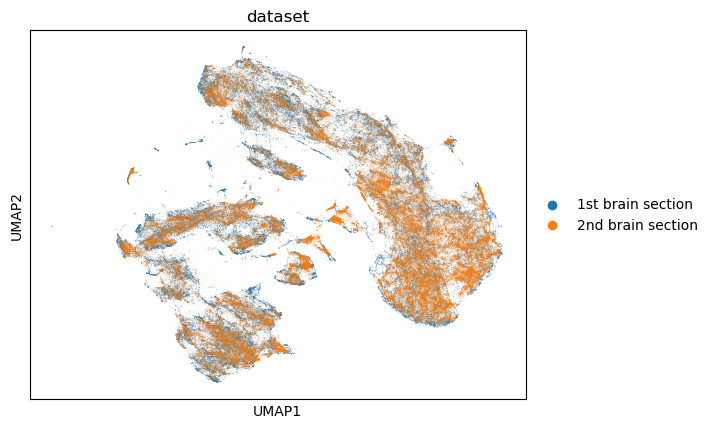

In [8]:
sc.pl.umap(adata_both, color=["dataset"])

In [9]:
adata_both.obs['dataset'] == '2nd brain section'

cell
10031     False
100723    False
10157     False
10168     False
10223     False
          ...  
134995     True
134996     True
134997     True
134999     True
135000     True
Name: dataset, Length: 373817, dtype: bool

## 4. Run UMAP + Leiden with multiple random seeds
Harmony embedding is fixed. Only UMAP and Leiden vary across seeds.

In [ ]:
seeds = [38, 42, 7, 123, 256, 999, 2024, 314, 55, 77]

X_harm_1 = adata_both[adata_both.obs['dataset'] == '1st brain section'].obsm['X_pca_harmony']
X_harm_2 = adata_both[adata_both.obs['dataset'] == '2nd brain section'].obsm['X_pca_harmony']

run_labels = {}  # seed -> leiden labels for all cells

for seed in seeds:
    print(f"Seed {seed}...", end=" ")
    
    # UMAP
    reducer = umap.UMAP(n_neighbors=5, min_dist=0.1, n_components=2, random_state=seed)
    reducer.fit(X_harm_1)
    X_umap = np.vstack([reducer.transform(X_harm_1), reducer.transform(X_harm_2)])
    adata_both.obsm['X_umap'] = X_umap
    
    # Neighbors + Leiden
    sc.pp.neighbors(adata_both, n_neighbors=10, random_state=seed, use_rep='X_pca_harmony')
    sc.tl.leiden(adata_both, resolution=0.8, random_state=seed, key_added='leiden_temp')
    
    run_labels[seed] = adata_both.obs['leiden_temp'].values.copy()
    n_clust = adata_both.obs['leiden_temp'].nunique()
    print(f"{n_clust} clusters")

print(f"\nCompleted {len(seeds)} runs.")

### Save per-seed Leiden labels to a single h5ad (all cells)

Labels-only h5ad (zero features, just `obs` columns) keyed by cell ID. All
373,817 cells from both brains are kept; each `leiden_seed_X` column holds
the Leiden assignment from one UMAP+Leiden run at `random_state=X`. The
1st-brain filter happens later, only at the comparison stage, since the
paper labels exist for the 1st brain only.


In [ ]:
# Save the random-seed clustering results for ALL cells (both brains) as a
# labels-only AnnData with zero features. The 1st-brain restriction is only
# applied later when comparing against the paper baseline.

labels_df = pd.DataFrame(
    {f'leiden_seed_{s}': pd.Categorical(
        np.asarray(run_labels[s]).astype(str))
     for s in seeds},
    index=adata_both.obs_names.astype(str),
)

# Keep brain identity so the file is splittable per brain without joining back.
labels_df['dataset'] = adata_both.obs['dataset'].values

out = 'harmony_seed_clustering_labels.h5ad'
labels_only = ad.AnnData(
    X=np.empty((len(labels_df), 0), dtype=np.float32),
    obs=labels_df,
)
labels_only.write_h5ad(out)

print(f"Wrote {out}")
print(f"  Cells (both brains): {labels_only.n_obs}")
print(f"  Columns: {list(labels_only.obs.columns)}")


In [15]:
# Reload seeds and run_labels so sections 5-8 can be rerun without re-doing
# the heavy UMAP+Leiden loop in section 4. adata_saved_1st (loaded in
# section 1) is used as the 1st-brain row-order reference; adata_both is
# aliased to it so downstream cells that reference adata_both keep working.
adata_both = adata_saved_1st
seeds = [38, 42, 7, 123, 256, 999, 2024, 314, 55, 77]

# The saved labels file is keyed by cell ID and holds both brains; the same
# cell ID can appear in both sections, so obs_names are non-unique and
# AnnData fancy-indexing on it would fail. Restrict to 1st brain in pandas,
# drop any residual duplicates, then reindex to adata_saved_1st's row order.
_labels_only = ad.read_h5ad('harmony_seed_clustering_labels.h5ad')
_b1_mask = (_labels_only.obs['dataset'] == '1st brain section').values
_obs_b1 = _labels_only.obs.iloc[_b1_mask]
_obs_b1.index = _obs_b1.index.astype(str)
_obs_b1 = _obs_b1[~_obs_b1.index.duplicated(keep='first')]
_obs_b1 = _obs_b1.reindex(adata_saved_1st.obs_names.astype(str))
if _obs_b1.isna().any().any():
    raise RuntimeError("Some cells in adata_saved_1st have no saved seed labels")

run_labels = {s: _obs_b1[f'leiden_seed_{s}'].astype(str).values for s in seeds}
print(f"Loaded run_labels for {len(run_labels)} seeds, "
      f"{len(next(iter(run_labels.values())))} cells each.")

Loaded run_labels for 10 seeds, 194824 cells each.


C:\Users\liany\AppData\Local\anaconda3\Lib\site-packages\anndata\_core\aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
C:\Users\liany\AppData\Local\anaconda3\Lib\site-packages\anndata\_core\anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## 5. Compare each run against the presented cell clustering

In [17]:
# Comparison restricted to the 1st brain -- the paper labels exist for the
# 1st brain only (adata_saved may already be a 1st-brain-only file with fewer
# cells than adata_both). Align by obs_names rather than assuming row counts
# match.

# Identify the 1st-brain dataset key (handle both spellings).
ds_vals = set(adata_both.obs['dataset'].unique().tolist())
b1_key = next((k for k in ('1st_brain', '1st brain section') if k in ds_vals), None)
if b1_key is None:
    raise RuntimeError(f"Cannot find 1st-brain dataset key: {ds_vals}")

# Row positions of 1st-brain cells in adata_both (these index into run_labels).
mask_b1 = (adata_both.obs['dataset'] == b1_key).values
b1_positions_in_both = np.where(mask_b1)[0]
b1_obs_names_in_both = adata_both.obs_names[b1_positions_in_both].astype(str)

# Cells common to (i) 1st brain in adata_both AND (ii) the paper file.
saved_obs_names = adata_saved_1st.obs_names.astype(str)
common_obs = pd.Index(b1_obs_names_in_both).intersection(pd.Index(saved_obs_names))
if len(common_obs) == 0:
    raise RuntimeError("No overlap between 1st-brain cells in adata_both and adata_saved")

# Position arrays for both adatas, aligned to common_obs order.
b1_name_to_both_pos = dict(zip(b1_obs_names_in_both, b1_positions_in_both))
both_positions = np.array([b1_name_to_both_pos[n] for n in common_obs])
saved_positions = adata_saved_1st.obs_names.astype(str).get_indexer(common_obs)

# Paper Leiden labels for the aligned subset, dropping any with NaN.
saved_labels_full = adata_saved_1st.obs['leiden'].astype(str).values[saved_positions]
mask_paper_valid = (saved_labels_full != 'nan') & (pd.notna(saved_labels_full))
both_positions = both_positions[mask_paper_valid]
saved_labels_valid = saved_labels_full[mask_paper_valid]

print(f"Total cells (adata_both):       {adata_both.n_obs}")
print(f"Total cells (adata_saved):      {adata_saved_1st.n_obs}")
print(f"1st-brain cells in adata_both:  {int(mask_b1.sum())}")
print(f"Cells used for comparison:      {len(saved_labels_valid)}")
print(f"Paper clusters:                 {len(set(saved_labels_valid))}")

print("\nComparison with saved paper clustering (1st brain):")
print(f"{'Seed':>6}  {'ARI':>7}  {'NMI':>7}  {'n_clusters':>10}")
print("-" * 35)

comparison_results = []
for seed in seeds:
    fresh_labels = np.asarray(run_labels[seed])[both_positions]
    ari = adjusted_rand_score(saved_labels_valid, fresh_labels)
    nmi = normalized_mutual_info_score(saved_labels_valid, fresh_labels)
    n_clust = len(set(fresh_labels))
    comparison_results.append({'seed': seed, 'ari': ari, 'nmi': nmi, 'n_clusters': n_clust})
    print(f"{seed:>6}  {ari:>7.4f}  {nmi:>7.4f}  {n_clust:>10}")

comp_df = pd.DataFrame(comparison_results)
print(f"\nMean ARI: {comp_df['ari'].mean():.4f} +/- {comp_df['ari'].std():.4f}")
print(f"Mean NMI: {comp_df['nmi'].mean():.4f} +/- {comp_df['nmi'].std():.4f}")

# Aliases kept for the section-6 pairwise cell.
# It uses run_labels[seed][valid_mask] expecting an array indexed by
# adata_both row order; we provide an integer-position array instead.
valid_mask = both_positions


Total cells (adata_both):       194824
Total cells (adata_saved):      194824
1st-brain cells in adata_both:  194824
Cells used for comparison:      194824
Paper clusters:                 27

Comparison with saved paper clustering (1st brain):
  Seed      ARI      NMI  n_clusters
-----------------------------------
    38   0.7015   0.8087          32
    42   0.6398   0.8017          28
     7   0.5536   0.7727          31
   123   0.6360   0.7855          33
   256   0.6606   0.8124          31
   999   0.5723   0.7670          31
  2024   0.6034   0.7904          32
   314   0.6203   0.7978          33
    55   0.6077   0.7855          33
    77   0.6379   0.7997          31

Mean ARI: 0.6233 +/- 0.0425
Mean NMI: 0.7921 +/- 0.0148


## 6. Pairwise ARI/NMI across all runs (including saved)

In [30]:
all_labels = {'Fig. 5': saved_labels_valid}
for seed in seeds:
    all_labels[f'seed_{seed}'] = run_labels[seed][valid_mask]

method_names = list(all_labels.keys())
n = len(method_names)

ari_matrix = np.ones((n, n))
nmi_matrix = np.ones((n, n))

for i in range(n):
    for j in range(i + 1, n):
        ari = adjusted_rand_score(all_labels[method_names[i]], all_labels[method_names[j]])
        nmi = normalized_mutual_info_score(all_labels[method_names[i]], all_labels[method_names[j]])
        ari_matrix[i, j] = ari
        ari_matrix[j, i] = ari
        nmi_matrix[i, j] = nmi
        nmi_matrix[j, i] = nmi

ari_df = pd.DataFrame(ari_matrix, index=method_names, columns=method_names)
nmi_df = pd.DataFrame(nmi_matrix, index=method_names, columns=method_names)

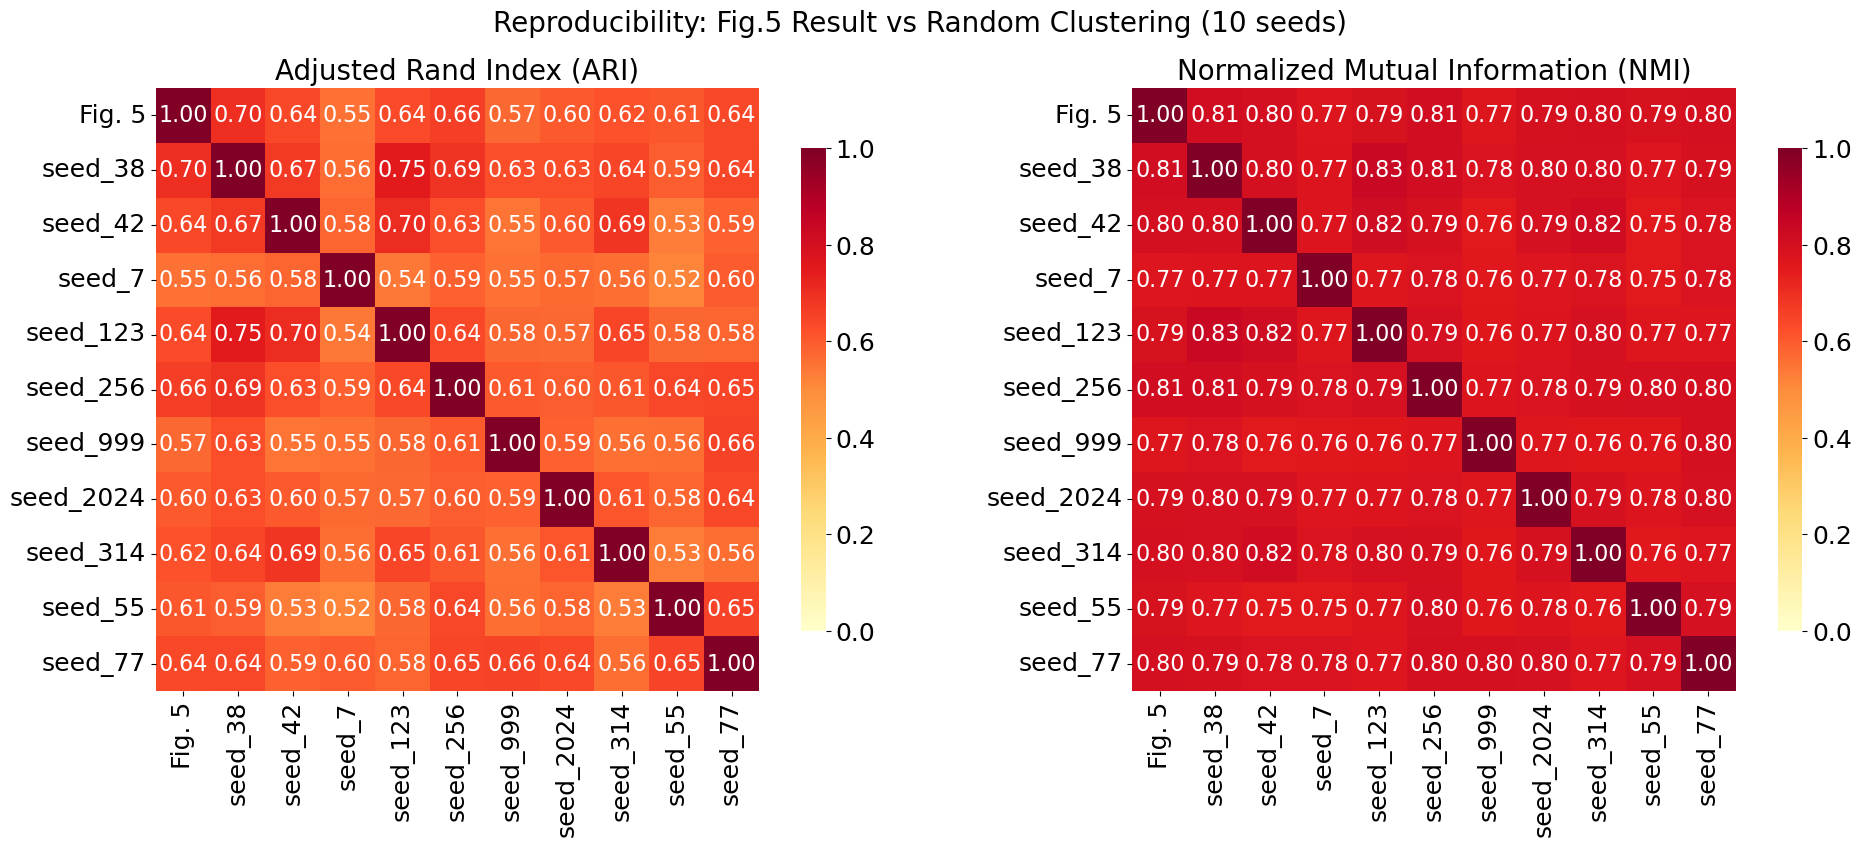

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
                                      
# Larger annotation numbers + larger row/col labels via tick_params.
sns.heatmap(ari_df, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1,                                                                                    
          square=True, ax=axes[0], cbar_kws={'shrink': 0.8},
          annot_kws={'size': 16})                                                                                                                          
axes[0].set_title('Adjusted Rand Index (ARI)', fontsize=20)
axes[0].tick_params(axis='both', labelsize=18)
axes[0].collections[0].colorbar.ax.tick_params(labelsize=18)

sns.heatmap(nmi_df, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1,
          square=True, ax=axes[1], cbar_kws={'shrink': 0.8},
          annot_kws={'size': 16})
axes[1].set_title('Normalized Mutual Information (NMI)', fontsize=20)
axes[1].tick_params(axis='both', labelsize=18)
axes[1].collections[0].colorbar.ax.tick_params(labelsize=18)

plt.suptitle('Reproducibility: Fig.5 Result vs Random Clustering (10 seeds)',
           fontsize=20, y=1.02)
plt.tight_layout()
plt.savefig('clustering_reproducibility_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Summary statistics

In [ ]:
# Off-diagonal values (excluding self-comparisons)
ari_vals = ari_matrix[np.triu_indices(n, k=1)]
nmi_vals = nmi_matrix[np.triu_indices(n, k=1)]

print(f"All pairwise comparisons ({len(ari_vals)} pairs):")
print(f"  ARI: mean={ari_vals.mean():.4f}, min={ari_vals.min():.4f}, max={ari_vals.max():.4f}, std={ari_vals.std():.4f}")
print(f"  NMI: mean={nmi_vals.mean():.4f}, min={nmi_vals.min():.4f}, max={nmi_vals.max():.4f}, std={nmi_vals.std():.4f}")

# Save
comp_df.to_csv('clustering_reproducibility_vs_paper.csv', index=False)
ari_df.to_csv('clustering_reproducibility_ARI_matrix.csv')
nmi_df.to_csv('clustering_reproducibility_NMI_matrix.csv')
print("\nSaved CSVs.")

## 8. Cluster characterization across seeds (1st brain)

Apply the cell-type analysis from the PCA-clustering sensitivity notebook
to the seed-by-seed Leiden runs above. Side-by-side panels show that the
cluster spatial pattern is stable across random seeds and the saved paper
result.

### Section 8 configuration

All paths and tunable parameters used by the cells below live in this single
block. Edit the values, re-run this cell, then re-run the section-8 cells
that follow (setup, composite). Nothing else needs to be touched.


In [23]:
# === User-configurable parameters for section 8 ===
import os

# --- Output directory and filename prefix (prepended to every CSV/PDF) ---
OUTPUT_DIR = 'output/'
OUTPUT_PREFIX = ''   # e.g. 'reproducibility_' to isolate outputs

def _outpath(name):
    """Resolve `name` against OUTPUT_DIR with OUTPUT_PREFIX prepended."""
    return os.path.join(OUTPUT_DIR, f"{OUTPUT_PREFIX}{name}")

# --- 1st-brain dataset key (auto-detected from adata_both.obs['dataset']) ---
B1_DATASET_KEY_CANDIDATES = ('1st_brain', '1st brain section')

# --- Section-8 plot panels (paper auto-included) ---
SELECTED_SEEDS = [38, 42, 7, 123, 256]

# --- Composite-figure inputs ---
COMPOSITE_EXAMPLE_KEYS = ['seed_38', 'seed_42', 'seed_7', 'seed_123']
COMPOSITE_MIN_CELLS = 500            # drop clusters with fewer cells from composite
SPATIAL_ROTATION_DEG = -137          # spatial-coord rotation (degrees)

# --- Composite-figure styling ---
DOT_SIZE = 0.15
TITLE_FS = 18
AXIS_LABEL_FS = 14
TICK_FS = 12
CLUSTER_LABEL_FS = 8

# Resolve the 1st-brain dataset key from adata_both.
_ds_vals = set(adata_both.obs['dataset'].unique().tolist())
B1_KEY = next((k for k in B1_DATASET_KEY_CANDIDATES if k in _ds_vals), None)
if B1_KEY is None:
    raise RuntimeError(f"Cannot find 1st-brain dataset key in {_ds_vals}")
print(f"Using 1st-brain dataset key: {B1_KEY!r}")
print(f"Output directory:           {os.path.abspath(OUTPUT_DIR)!r}")
print(f"Output prefix:              {OUTPUT_PREFIX!r}")

Using 1st-brain dataset key: '1st brain section'
Output directory:           'h:\\53Ab_wholebrain7.17.25\\3rd_wholebrain_output\\Step5\\final_codes\\vii_Validation_robustness_tests\\output'
Output prefix:              ''


In [24]:
# Build a 1st-brain plotting AnnData with the paper Leiden labels and the
# labels from the seeds listed in SELECTED_SEEDS. UMAP coords come from the
# saved paper result so all panels share the same embedding. All inputs and
# parameters come from the section-8 configuration cell above.
import warnings
warnings.filterwarnings("ignore")

# Mask 1st-brain rows in adata_both.
mask_b1 = (adata_both.obs['dataset'] == B1_KEY).values
b1_obs_names = adata_both.obs_names[mask_b1].astype(str)

# Cells common to (i) 1st brain in adata_both and (ii) the saved paper
# file. Align via obs_names because the two sources may have different
# cell counts.
saved_obs_names = adata_saved_1st.obs_names.astype(str)
common_cells = pd.Index(b1_obs_names).intersection(pd.Index(saved_obs_names))
if len(common_cells) == 0:
    raise RuntimeError("No overlap between 1st-brain cells and paper file")

# Labels-only AnnData (zero features) -- just carries obsm/obs for plotting.
adata_plot = ad.AnnData(
    X=np.empty((len(common_cells), 0), dtype=np.float32),
    obs=pd.DataFrame(index=common_cells),
)

# Position arrays for the common cells in adata_both (used to slice
# run_labels) and in adata_saved_1st (used to slice obsm/obs of the paper).
b1_name_to_both_pos = dict(zip(b1_obs_names, np.where(mask_b1)[0]))
both_positions = np.array([b1_name_to_both_pos[c] for c in common_cells])
saved_positions = adata_saved_1st.obs_names.astype(str).get_indexer(common_cells)

# Spatial coords from adata_both, UMAP coords from the saved paper file.
adata_plot.obsm['spatial'] = adata_both.obsm['spatial'][both_positions]
adata_plot.obsm['X_umap'] = adata_saved_1st.obsm['X_umap'][saved_positions]

# Cluster labels: paper + the seeds listed in the config cell.
label_keys = ['paper'] + [f'seed_{s}' for s in SELECTED_SEEDS]

paper_lab = adata_saved_1st.obs['leiden'].astype(str).values[saved_positions]
adata_plot.obs['paper'] = pd.Categorical(paper_lab)
for s in SELECTED_SEEDS:
    seed_lab = np.asarray(run_labels[s])[both_positions].astype(str)
    adata_plot.obs[f'seed_{s}'] = pd.Categorical(seed_lab)

print(f"adata_plot: {adata_plot.n_obs} cells")
print(f"Label sets: {label_keys}")

adata_plot: 194824 cells
Label sets: ['paper', 'seed_38', 'seed_42', 'seed_7', 'seed_123', 'seed_256']


### Composite figure: UMAP / spatial

One row per example clustering result. Cluster colors are synchronized
between the UMAP (col 1) and spatial (col 2) panels within each row.

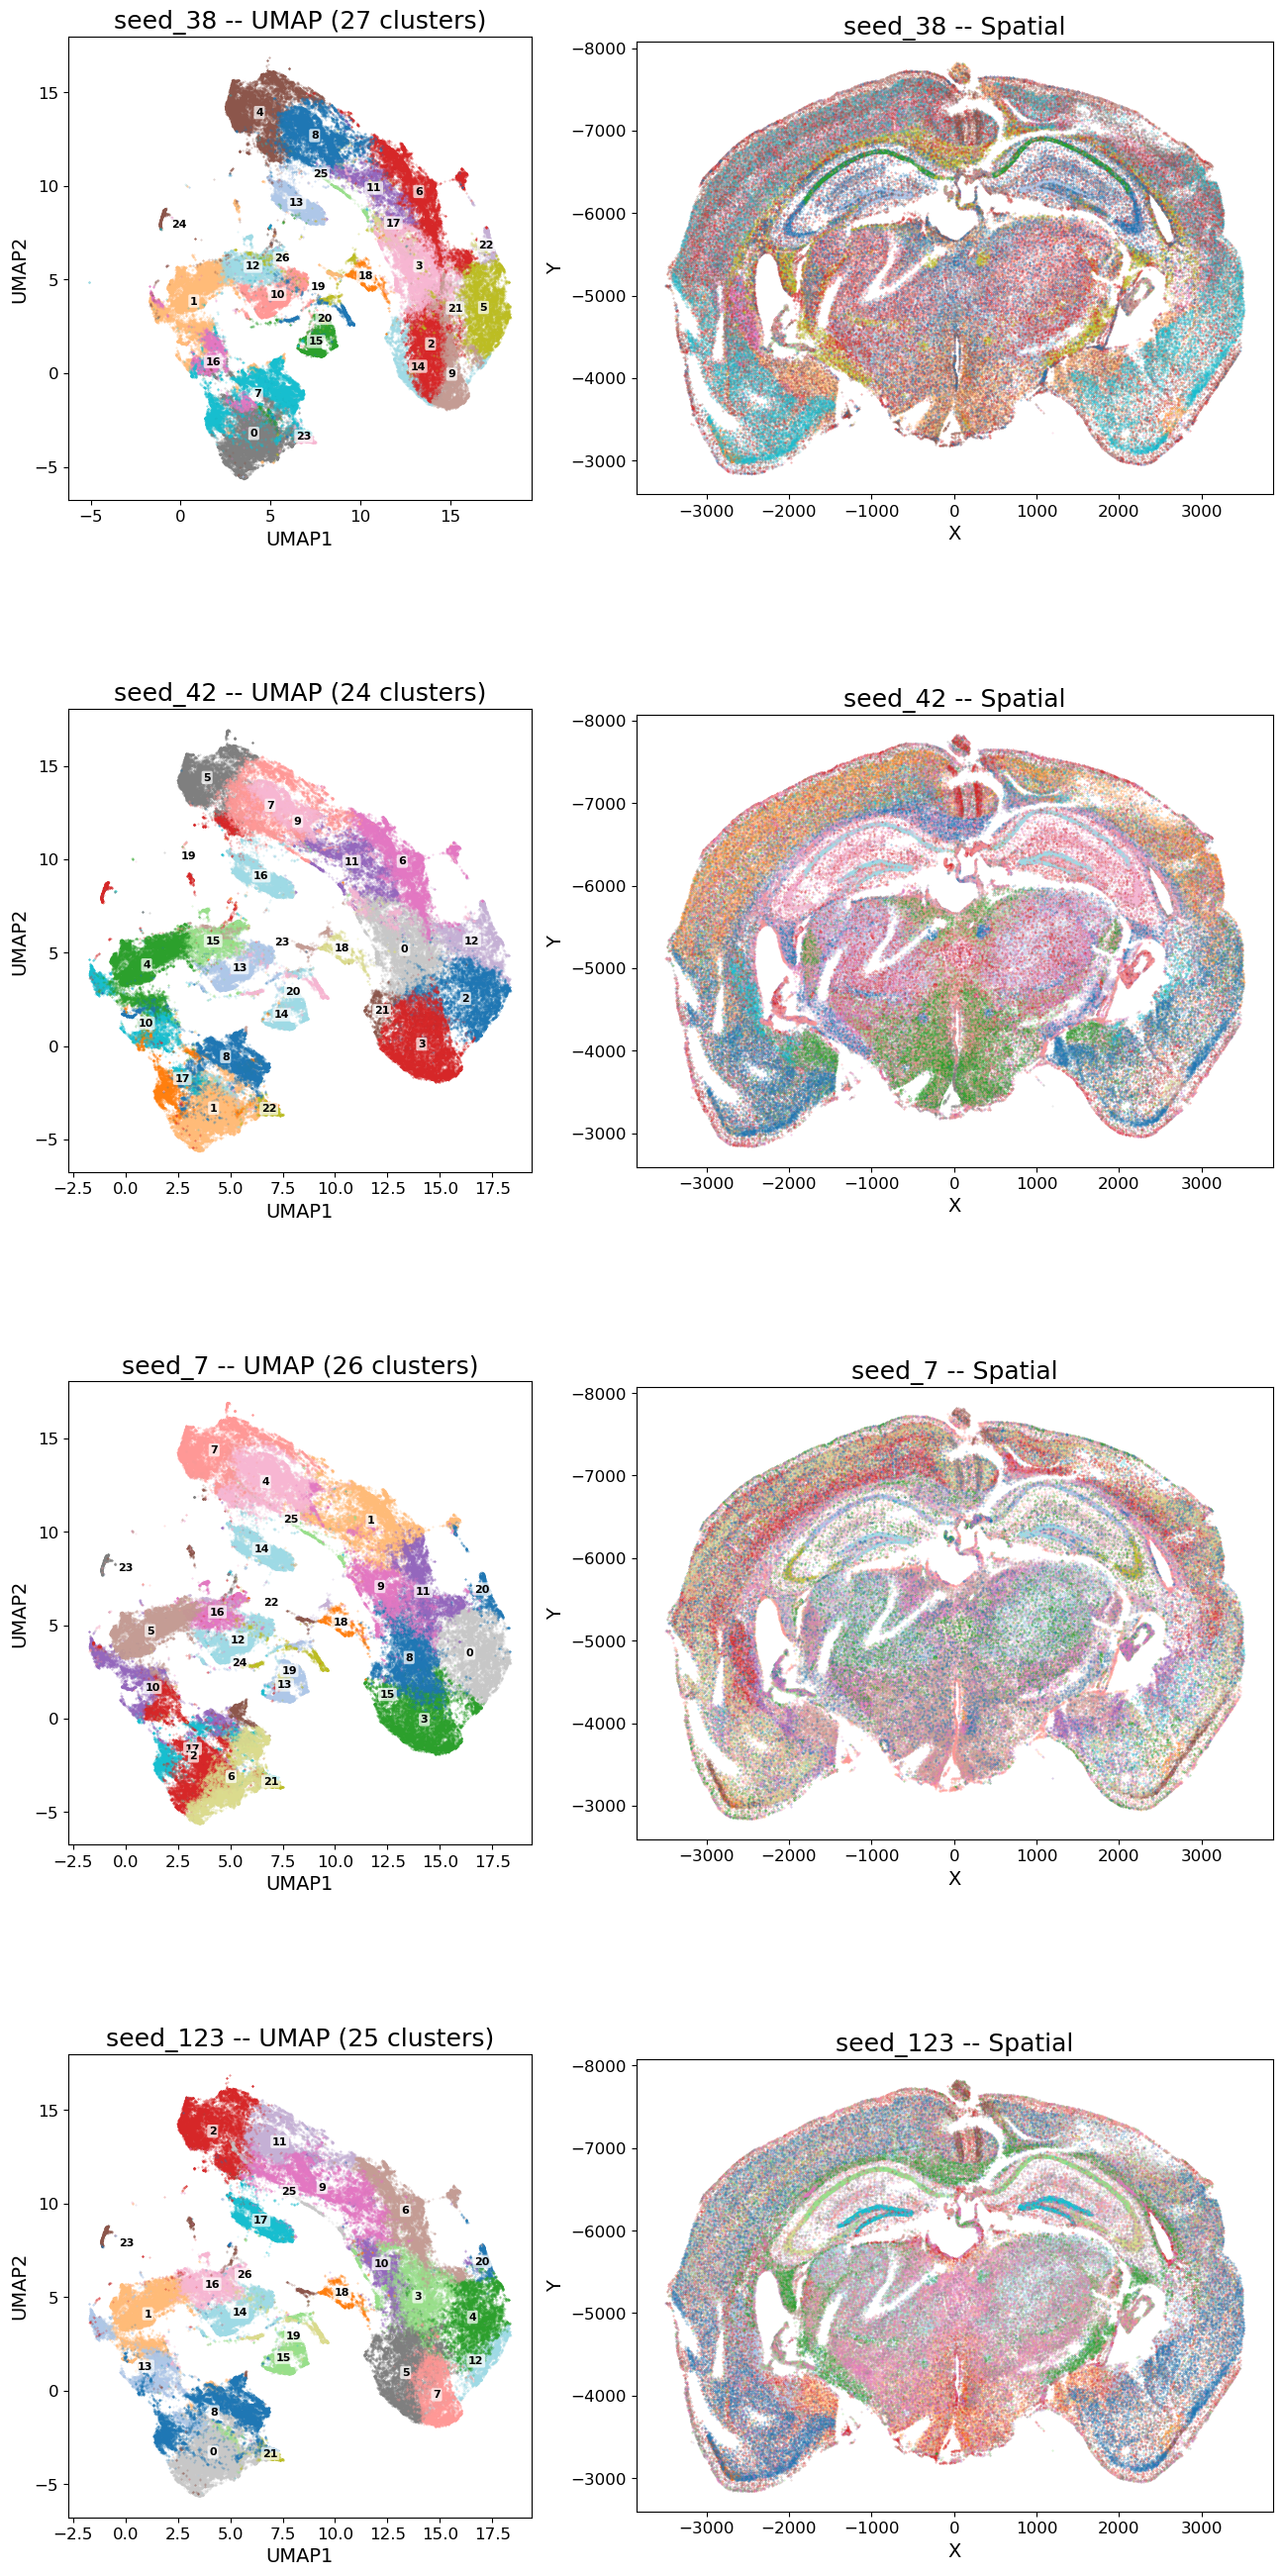

In [26]:
# Composite figure: UMAP / spatial.
# All inputs and styling parameters come from the section-8 configuration
# cell at the top of section 8 -- edit there, not here.
example_keys = COMPOSITE_EXAMPLE_KEYS
n_rows = len(example_keys)


# Rotate the spatial coordinates before plotting so anatomical landmarks
# point in the conventional orientation. Always recompute on rerun in case
# the user changed SPATIAL_ROTATION_DEG in the config cell.
_theta = np.radians(SPATIAL_ROTATION_DEG)
_R = np.array([
    [np.cos(_theta), -np.sin(_theta)],
    [np.sin(_theta),  np.cos(_theta)],
])
adata_plot.obsm['spatial_rotated'] = adata_plot.obsm['spatial'] @ _R.T

# Shuffle the categorical-color order so adjacent cluster IDs do not get
# perceptually adjacent tab20 colors. Stable across runs because of the seed.
def _shuffled_palette(n, seed=0):
    base = plt.cm.get_cmap("tab20", max(n, 20))
    rng = np.random.default_rng(seed)
    perm = rng.permutation(max(n, 20))
    return [base(int(p)) for p in perm[:n]]

fig, axes = plt.subplots(
    n_rows, 2,
    figsize=(13.06, 8 * n_rows),
    gridspec_kw={'width_ratios': [5.5, 7.56]},  # spatial keeps its size; UMAP cell is narrower
)
if n_rows == 1:
    axes = axes.reshape(1, 2)

for r, key in enumerate(example_keys):
    labels = adata_plot.obs[key].astype('category')
    cats_all = labels.cat.categories
    counts = labels.value_counts()
    keep = [c for c in cats_all if int(counts.get(c, 0)) >= COMPOSITE_MIN_CELLS]
    cats = pd.Index(keep)
    n_clust = len(cats)

    palette = _shuffled_palette(n_clust, seed=0)
    cluster_colors = {c: palette[i] for i, c in enumerate(cats)}

    # Col 1 -- UMAP
    ax = axes[r, 0]
    ax.set_box_aspect(1)  # keep UMAP square, sized down to the narrower cell width
    umap = adata_plot.obsm['X_umap']
    for cat in cats:
        mask = (labels == cat).values
        ax.scatter(umap[mask, 0], umap[mask, 1], s=DOT_SIZE,
                   c=[cluster_colors[cat]], alpha=0.4, rasterized=True)
        cx, cy = umap[mask, 0].mean(), umap[mask, 1].mean()
        ax.text(cx, cy, str(cat), fontsize=CLUSTER_LABEL_FS, fontweight='bold',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.7, lw=0))
    ax.set_title(
        f'{key} -- UMAP ({n_clust} clusters)',
        fontsize=TITLE_FS,
    )
    ax.set_xlabel('UMAP1', fontsize=AXIS_LABEL_FS)
    ax.set_ylabel('UMAP2', fontsize=AXIS_LABEL_FS)
    ax.tick_params(axis='both', labelsize=TICK_FS)

    # Col 2 -- Spatial (rotated; same cluster colors as col 1).
    ax = axes[r, 1]
    xy = adata_plot.obsm['spatial_rotated']
    for cat in cats:
        mask = (labels == cat).values
        ax.scatter(xy[mask, 0], xy[mask, 1], s=DOT_SIZE,
                   c=[cluster_colors[cat]], alpha=0.5, rasterized=True)
    ax.set_title(f'{key} -- Spatial',
                  fontsize=TITLE_FS)
    ax.set_xlabel('X', fontsize=AXIS_LABEL_FS)
    ax.set_ylabel('Y', fontsize=AXIS_LABEL_FS)
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.set_aspect('equal'); ax.invert_yaxis()

plt.tight_layout()
plt.subplots_adjust(hspace=-0.4)
plt.savefig(_outpath('clustering_composite_reproducibility.pdf'), dpi=200, bbox_inches='tight')
plt.savefig(_outpath('clustering_composite_reproducibility.png'), dpi=200, bbox_inches='tight')
plt.show()